In [ ]:
!pip install kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:28<00:00, 16.6MB/s]



In [ ]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [ ]:
import os
print(os.listdir("chest_xray"))

['val', 'test', 'chest_xray', 'train', '__MACOSX']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
IMG_SIZE = 150

def load_data(folder):
    data = []
    for category in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(folder, category)
        label = 0 if category == "NORMAL" else 1

        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img))
                img_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append([img_array, label])
            except:
                pass
    return data

train_data = load_data("chest_xray/train")

In [ ]:
random.shuffle(train_data)

X = []
y = []

for features, label in train_data:
    X.append(features)
    y.append(label)

X = np.array(X) / 255.0   # normalize
y = np.array(y)

print(X.shape)
print(y.shape)

(5216, 150, 150, 3)
(5216,)


In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X, y,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.8852 - loss: 0.3051 - val_accuracy: 0.9617 - val_loss: 0.1210
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9533 - loss: 0.1275 - val_accuracy: 0.9655 - val_loss: 0.0943
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9614 - loss: 0.1049 - val_accuracy: 0.9579 - val_loss: 0.1198
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9717 - loss: 0.0838 - val_accuracy: 0.9722 - val_loss: 0.0843
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9744 - loss: 0.0722 - val_accuracy: 0.9665 - val_loss: 0.0865
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9767 - loss: 0.0574 - val_accuracy: 0.9741 - val_loss: 0.0769
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9832 - loss: 0.0494 - val_accuracy: 0.9674 - val_loss: 0.0961
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9873 - loss: 0.0359 - val_acc

In [ ]:
model.save("pneumonia_model.h5")

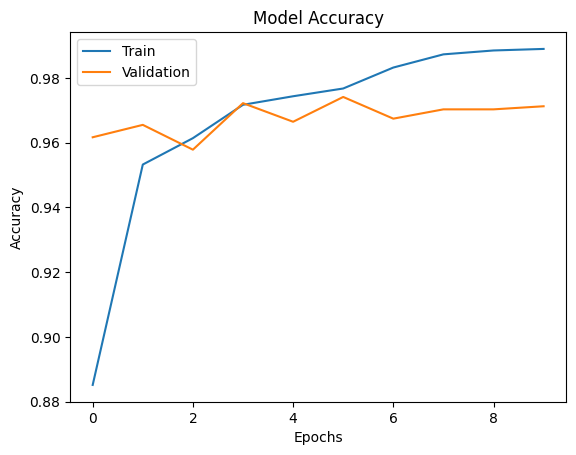

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model.predict(X) > 0.5).astype("int32")

print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
[[1326   15]
 [  32 3843]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1341
           1       1.00      0.99      0.99      3875

    accuracy                           0.99      5216
   macro avg       0.99      0.99      0.99      5216
weighted avg       0.99      0.99      0.99      5216



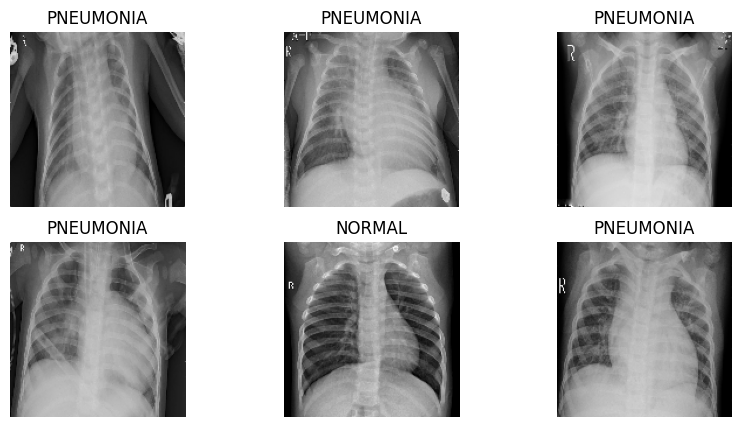

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X[i])
    plt.title("PNEUMONIA" if y[i]==1 else "NORMAL")
    plt.axis('off')

plt.show()

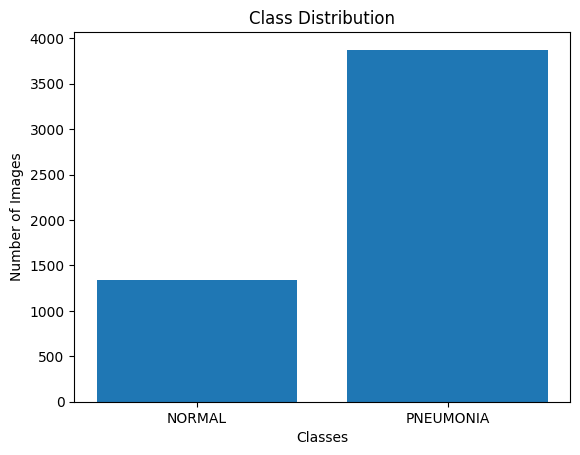

In [ ]:
labels = ["NORMAL", "PNEUMONIA"]
counts = [0, 0]

for _, label in train_data:
    counts[label] += 1

plt.bar(labels, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

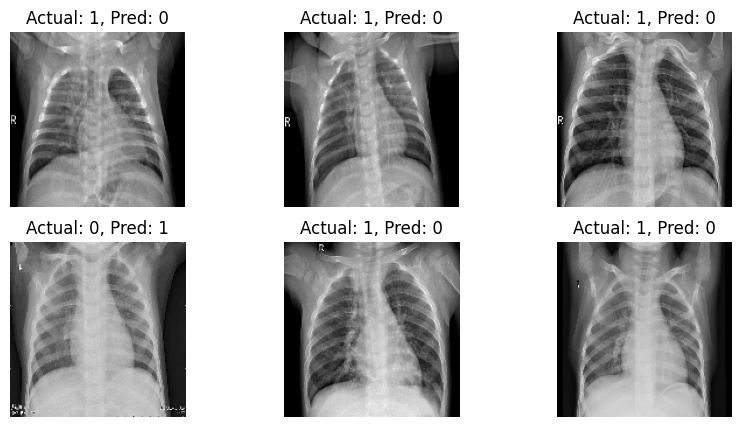

In [ ]:
misclassified = np.where(y != y_pred.flatten())[0]

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified[:6]):
    plt.subplot(2,3,i+1)
    plt.imshow(X[idx])
    plt.title(f"Actual: {y[idx]}, Pred: {y_pred[idx][0]}")
    plt.axis('off')

plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving p9t85GYhc3Umaq68hLZQ_RackMultipart20180207-1581-1xyzqzv.jpg to p9t85GYhc3Umaq68hLZQ_RackMultipart20180207-1581-1xyzqzv.jpg


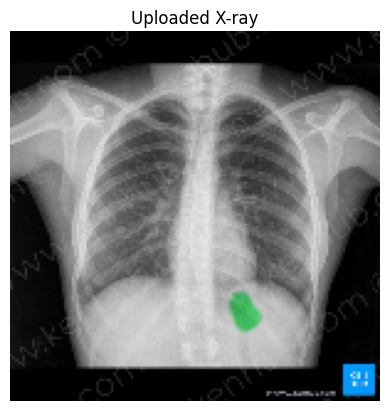

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 150

file_name = "p9t85GYhc3Umaq68hLZQ_RackMultipart20180207-1581-1xyzqzv.jpg"

img = cv2.imread(file_name)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Uploaded X-ray")
plt.axis('off')
plt.show()

In [ ]:
img = img / 255.0
img = np.reshape(img, (1, IMG_SIZE, IMG_SIZE, 3))

In [ ]:
prediction = model.predict(img)

confidence = prediction[0][0]

if confidence > 0.5:
    print(f"🩺 Pneumonia Detected ({confidence*100:.2f}%)")
else:
    print(f"✅ Normal ({(1-confidence)*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step
✅ Normal (99.97%)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-04-07 125243.png to Screenshot 2026-04-07 125243 (1).png


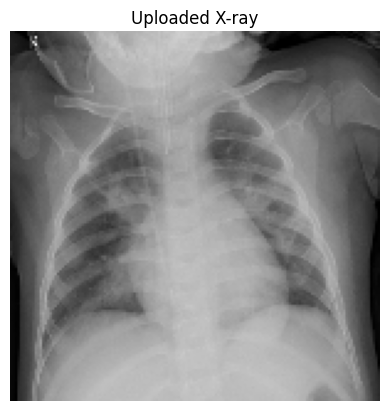

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 150

file_name = "Screenshot 2026-04-07 125243.png"

img = cv2.imread(file_name)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Uploaded X-ray")
plt.axis('off')
plt.show()

In [ ]:
import cv2
import numpy as np

img_path = "Screenshot 2026-04-07 125243.png"  # your file name

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (150, 150))

img = img.reshape(1, 150, 150, 1) / 255.0

In [ ]:
import cv2
import numpy as np

img_path = "Screenshot 2026-04-07 125243.png"

# Load as COLOR (3 channels)
img = cv2.imread(img_path)

# Resize
img = cv2.resize(img, (150, 150))

# Normalize + reshape
img = img.reshape(1, 150, 150, 3) / 255.0

# Predict
prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("🫁 PNEUMONIA")
else:
    print("✅ NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
🫁 PNEUMONIA
